## PII+Image Redactor Example Notebook


**Author**: Shahrokh Daijavad,
**email**:shahrokh@us.ibm.com

### Summary

In the [PII recipe](../PII/Run_your_first_PII_redactor_transform.ipynb), it is shown how the basic PII (Personally Identifiable Information) Redactor is used to identify and redact sensitive information in text data, such as  
Names, Email addresses, Phone numbers, Addresses, and Financial details (e.g., credit card numbers and crypto addresses). Here we want to show one of the Multimedia tranforms in DPK that will be used to blur the face of an image in a document, as an additional step in applying PII redaction beyond text. 

 **Workflow Overview**

- **Extracting and Converting Text and Image:** The content of a hypothetical invoice, originally in PDF format, is processed using the docling2parquet transform to extract both the text and image and convert them into a structured Parquet file, enabling easier handling and downstream processing by other DPK transforms. 

- **Redacting Sensitive Text Information:** The generated Parquet file serves as the input for the dpk_pii_redactor transform. This step scans the invoice data for personally identifiable information (PII) and applies masking techniques to redact any sensitive content, ensuring data privacy and compliance.

- **Redacting Image using a face-blurring technique:** The generated output Parquet file from the previous stage serves as the input for the images/people transform. This step scans the input file, detects the face in the image and blurrs the face for additional data privacy. 


## How to run this notebook

If you have python 3.11 or higher on your machine, you can also download the notebook and run it locally using a local python environment setup as follows:

```
python -m venv venv
source venv/bin/activate
pip install jupyterlab
jupyter lab PII_Image_redactor.ipynb
```

For more advanced setup, please see setup [guide](https://github.com/data-prep-kit/data-prep-kit/blob/dev/doc/quick-start/quick-start.md).


### Pre-req: Install data-prep-kit toolkit

In [1]:

%pip install "data-prep-toolkit-transforms[docling2parquet,pii_redactor]==1.1.7.dev3"
%pip install pandas 
import pandas as pd
import os

  Using cached opencv_python-4.10.0.84-cp37-abi3-macosx_11_0_arm64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-macosx_11_0_arm64.whl (54.8 MB)
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.11.0.86
    Uninstalling opencv-python-4.11.0.86:
      Successfully uninstalled opencv-python-4.11.0.86

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 1: Configuration

### Download Data and set input and output directories
#### We will place the downloaded input files in the `tmp/input` directory. For our use case, we have used a typical invoice data file, `Invoiceplusimage.pdf`, which contains an image and will undergo processing. The output for each transform run will be generated in separate sub-directories under the ouput directory, with directory names following the format `files_<transform_name>`, making it easy to verify the respective transform outputs. This concludes the setup section.

In [2]:
#import urllib.request
import shutil
shutil.os.makedirs("tmp/input", exist_ok=True)
#urllib.request.urlretrieve("https://raw.githubusercontent.com/data-prep-kit/data-prep-kit/dev/recipes/input-data/PII-image/Invoiceplusimage.pdf", "tmp/input/Invoiceplusimage.pdf")

input_dir = "tmp/input"
output_dir = "output"
output_docling2pq_dir = os.path.join (output_dir, 'files_docling2parquet')
output_piiredactor_dir = os.path.join (output_dir, 'files_piiredacted')
output_people_dir = os.path.join (output_dir, 'files_people')

## Display the input PDF file

In [3]:
from IPython.display import IFrame
IFrame(src=f"{input_dir}/Invoiceplusimage.pdf", width=600, height=800)

## Step 2: Invoke Docling2Parquet transform to proces pdf files

In [4]:
from dpk_docling2parquet import Docling2Parquet
from data_processing.utils import GB
from dpk_docling2parquet.transform import docling2parquet_contents_types

In [5]:

%%time

from dpk_docling2parquet import Docling2Parquet
from data_processing.utils import GB
from dpk_docling2parquet import docling2parquet_contents_types

STAGE = 1
print (f"🏃🏼 STAGE-{STAGE}: Processing input='{input_dir}' --> output='{output_docling2pq_dir}'\n", flush=True)

Docling2Parquet(input_folder= input_dir,
               output_folder= output_docling2pq_dir,
               data_files_to_use=['.pdf'],
               docling2parquet_contents_type=docling2parquet_contents_types.MARKDOWN,
               docling2parquet_generate_picture_images=True,
               docling2parquet_pipeline="vlm").transform()

🏃🏼 STAGE-1: Processing input='tmp/input' --> output='output/files_docling2parquet'



14:01:03 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/dpk_docling2parquet/transform.py:676 - docling2parquet parameters are : {'batch_size': -1, 'artifacts_path': 
None, 'contents_type': <docling2parquet_contents_types.MARKDOWN: 'text/markdown'>, 'do_table_structure': True, 
'do_ocr': True, 'ocr_engine': <docling2parquet_ocr_engine.EASYOCR: 'easyocr'>, 'bitmap_area_threshold': 0.05, 
'pdf_backend': <docling2parquet_pdf_backend.DLPARSE_V2: 'dlparse_v2'>, 'double_precision': 8, 'pipeline': 
<docling2parquet_pipeline.VLM: 'vlm'>, 'generate_picture_images': True, 'generate_page_images': False, 
'images_scale': 2.0}
taskName=Task-52

14:01:03 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/execution_configuration.py:91 - pipeline id pipeline_id
taskName=Task-52

14:01:03 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/execution_configuration.py:94 - code location {'github': 'UNDEFINED', 'build-date': 
'UNDEFINED', 'commit_hash': 'UNDEFINED', 'path': 'UNDEFINED'}
taskName=Task-52

14:01:03 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/data_access/data_access_factory.py:257 - data factory data_ max_files -1, n_sample -1
taskName=Task-52

...

14:01:12 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_orchestrator.py:201 - Done processing 1 files, waiting for flush()
completion.
taskName=Task-52

14:01:12 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_orchestrator.py:205 - done flushing in 0.0 sec
taskName=Task-52

14:01:12 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_launcher.py:65 - Completed execution in 0.137 min, execution 
result 0
taskName=Task-52

CPU times: user 4.3 s, sys: 1.58 s, total: 5.88 s
Wall time: 8.23 s


0

## Step 3: Invoke PII Redactor redaction transform

In [6]:
%%time

from dpk_pii_redactor import PIIRedactor

STAGE = 2
print (f"🏃🏼 STAGE-{STAGE}: Processing input='{output_docling2pq_dir}' --> output='{output_piiredactor_dir}'\n", flush=True)
PIIRedactor(input_folder=output_docling2pq_dir,
            output_folder= output_piiredactor_dir,
            pii_redactor_entities = ["PERSON", "EMAIL_ADDRESS","ORGANIZATION","PHONE_NUMBER", "LOCATION","CRYPTO"],
            pii_redactor_operator = "replace",
            pii_redactor_transformed_contents = "title").transform()

🏃🏼 STAGE-2: Processing input='output/files_docling2parquet' --> output='output/files_piiredacted'



14:01:13 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/execution_configuration.py:91 - pipeline id pipeline_id
taskName=Task-55

14:01:13 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/execution_configuration.py:94 - code location {'github': 'UNDEFINED', 'build-date': 
'UNDEFINED', 'commit_hash': 'UNDEFINED', 'path': 'UNDEFINED'}
taskName=Task-55

14:01:13 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/data_access/data_access_factory.py:257 - data factory data_ max_files -1, n_sample -1
taskName=Task-55

14:01:13 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/data_access/data_access_factory.py:271 - data factory data_ Not using data sets, checkpointing 
False, max files -1, random samples -1, files to use ['.parquet'], files to checkpoint ['.parquet']
taskName=Task-55

...

14:01:27 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_orchestrator.py:201 - Done processing 1 files, waiting for flush()
completion.
taskName=Task-55

14:01:27 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_orchestrator.py:205 - done flushing in 0.0 sec
taskName=Task-55

14:01:27 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_launcher.py:65 - Completed execution in 0.238 min, execution 
result 0
taskName=Task-55

CPU times: user 11.4 s, sys: 2.04 s, total: 13.5 s
Wall time: 15.7 s


0

## Step 4: Display Output in a Readable Format with masked PII information

In [7]:
data = pd.read_parquet('output/files_piiredacted/Invoiceplusimage.parquet')
print(data["title"][0])
print(data["detected_pii"][0])

<ORGANIZATION>.

Invoice Details:

Invoice Number: INV-2024-001

Invoice Date: November 15, 2024

Due Date: November 30, 2024

## INVOICE

<!-- image -->

Billing Information:

Customer Name: <PERSON>

Address: 123 <LOCATION>, Apt 45, <LOCATION>, <LOCATION> 62704

Email: <EMAIL_ADDRESS>

Phone: <PHONE_NUMBER>

Shipping Information:

Recipient Name: <PERSON>

Address: 123 <LOCATION>, Apt 45, <LOCATION>, <LOCATION> 62704

## Item Details:

| Description                |   Quantity | Unit Price   | Total   |
|----------------------------|------------|--------------|---------|
| MacBook Air (13-inch, M2)  |          1 | $999.00      | $999.00 |
| AppleCare+ for MacBook Air |          1 | $199.00      | $199.00 |

Subtotal: $1,198.00 Tax (8%): $95.84

Total Amount Due:

$1,293.84

Payment Method: Credit Card (Visa)

Transaction ID: 9876543210ABCDE

Notes:

Thank you for your purchase!

For assistance, please contact our support team at <EMAIL_ADDRESS> or 1-800-MYAPPLE.
['ORGANIZATION' 'PERS

## Step 5: Invoke People transform to blur the image from the Invoice file 

#### At this point, we need to download the model that the "people" transform uses 

In [8]:
shutil.os.makedirs("models", exist_ok=True)
!curl -L --output models/yolov8m_200e.pt https://huggingface.co/ZiqianLiu/yolov8_face/resolve/4b1db35121179d189754a3bf0b4a86aa44c03eef/yolov8m_200e.pt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1315  100  1315    0     0   3877      0 --:--:-- --:--:-- --:--:--  3890
100  197M  100  197M    0     0  13.2M      0  0:00:14  0:00:14 --:--:-- 12.2M


In [9]:
%pip install "data-prep-toolkit-transforms[people]==1.1.7.dev3"

  Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl.metadata (20 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl (37.3 MB)
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.10.0.84
    Uninstalling opencv-python-4.10.0.84:
      Successfully uninstalled opencv-python-4.10.0.84
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlx-vlm 0.3.1 requires opencv-python==4.10.0.84, but you have opencv-python 4.11.0.86 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
%%time

from dpk_people import People

STAGE = 3
print (f"🏃🏼 STAGE-{STAGE}: Processing input='{output_piiredactor_dir}' --> output='{output_people_dir}'\n", flush=True)

People(input_folder=output_piiredactor_dir,
    output_folder=output_people_dir,
    people_model_path="models/yolov8m_200e.pt",
).transform()

🏃🏼 STAGE-3: Processing input='output/files_piiredacted' --> output='output/files_people'



14:02:35 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/dpk_people/transform.py:256 - parameters are : {'model_path': 'models/yolov8m_200e.pt', 'mode': 'blur', 
'threshold': 0.6, 'batch_size': 50}
taskName=Task-67

14:02:35 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/execution_configuration.py:91 - pipeline id pipeline_id
taskName=Task-67

14:02:35 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/execution_configuration.py:94 - code location {'github': 'UNDEFINED', 'build-date': 
'UNDEFINED', 'commit_hash': 'UNDEFINED', 'path': 'UNDEFINED'}
taskName=Task-67

14:02:35 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/data_access/data_access_factory.py:257 - data factory data_ max_files -1, n_sample -1
taskName=Task-67

...

14:02:36 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_orchestrator.py:201 - Done processing 1 files, waiting for flush()
completion.
taskName=Task-67

14:02:36 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_orchestrator.py:205 - done flushing in 0.0 sec
taskName=Task-67

14:02:36 [INFO] 
/Users/shahrokhdaijavad/Documents/data-prep-kit-pii-imagenotebook/recipes/PII-image/venv/lib/python3.12/site-packag
es/data_processing/runtime/pure_python/transform_launcher.py:65 - Completed execution in 0.005 min, execution 
result 0
taskName=Task-67

CPU times: user 693 ms, sys: 484 ms, total: 1.18 s
Wall time: 11.4 s


0

In [11]:
import glob
glob.glob("output_people_dir/*")

[]

In [12]:
import pyarrow.parquet as pq
import pandas as pd

# Read the Parquet file into an Arrow Table
df = pq.read_table('output/files_people/Invoiceplusimage.parquet').to_pandas()
df.head()

,detected_pii,title,filename,contents,num_pages,num_tables,num_doc_elements,document_id,document_hash,ext,hash,size,date_acquired,document_convert_time,image_bins,orig_image_fpaths,num_pictures,source_filename,blurred_images,nfaces
0,"[ORGANIZATION, PERSON, LOCATION, LOCATION, LOC...",<ORGANIZATION>.\n\nInvoice Details:\n\nInvoice...,Invoiceplusimage.pdf,Apple Inc.\n\nInvoice Details:\n\nInvoice Numb...,2,1,27,f574fa04-451f-4d4a-b26d-488086bc717a,4e0168a77a96155f1388932668c440c1e7c0e75843e603...,pdf,fc30824d4fd25012a139808f62b8d73b3f7050851d6ea9...,967,2025-12-03T14:01:12.203348,8.193498,[b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00...,[/var/folders/jf/bgybw7w51l5bn636sw019jym0000g...,1,Invoiceplusimage.pdf,[b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00...,1


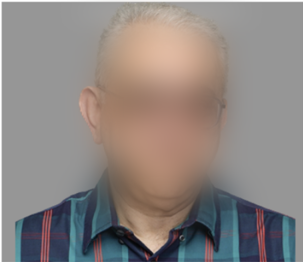

In [13]:
import io
from IPython.display import display
import PIL.Image as Image
    
image = Image.open(io.BytesIO(df.iloc[0]['blurred_images'][0]))
display(image)